把deepmimo的数据集作为cc的输入，度量学习考虑adp，运用传统典型方法、三元组、孪生网络等方法对比， gpu加速版本

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE, Isomap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm

# 检查GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 设置随机种子以复现结果
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [5]:
import os

# 1. 打印当前 Python 认为的"当前目录"
print("当前工作目录:", os.getcwd())

# 2. 打印当前目录下所有的文件
print("\n当前目录下的文件:", os.listdir(os.getcwd()))

当前工作目录: /mnt/cjr/tutorial

当前目录下的文件: ['deepmimo_dataset.pkl', 'generate_dataset.py', '1217.ipynb']


In [17]:
import pickle


print("正在读取数据集...")
# 'rb' 表示以二进制读取模式打开
with open('deepmimo_dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)

print("读取成功！")
print(f"基站数量: {len(dataset)}")
# 此时你可以直接运行之前的代码了
# X_features, Y_locs = generate_adp_features(dataset, bs_idx=0)

正在读取数据集...
读取成功！
基站数量: 2


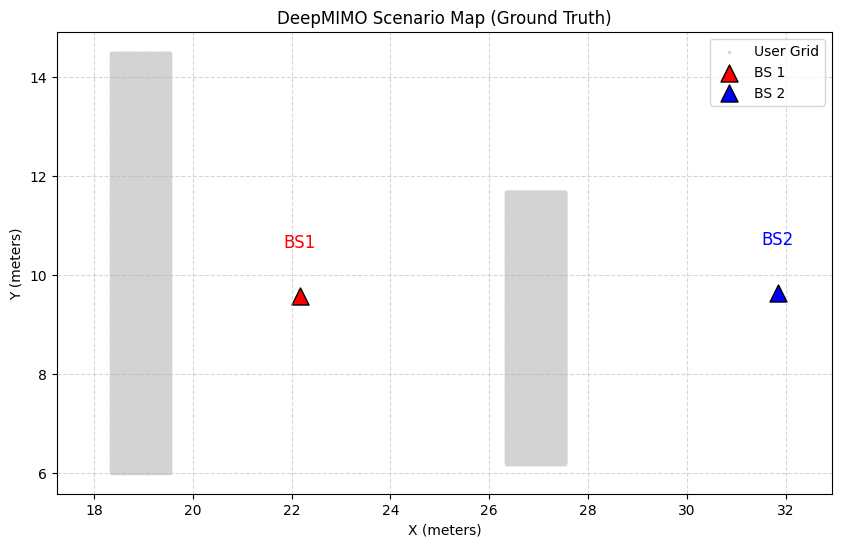

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scenario_map(dataset):
    # 1. 获取所有用户的 X, Y 坐标
    # DeepMIMO 的坐标通常是 (x, y, z)，我们取前两列
    user_locs = dataset[0]['user']['location']
    
    # 2. 获取基站坐标
    bs1_loc = dataset[0]['location']
    bs2_loc = dataset[1]['location']
    
    plt.figure(figsize=(10, 6))
    
    # 绘制用户区域 (灰色小点)
    plt.scatter(user_locs[:, 0], user_locs[:, 1], c='lightgray', s=2, label='User Grid')
    
    # 绘制 BS1 (红色)
    plt.scatter(bs1_loc[0], bs1_loc[1], c='red', s=150, marker='^', label='BS 1', edgecolors='black')
    plt.text(bs1_loc[0], bs1_loc[1]+1, 'BS1', fontsize=12, color='red', ha='center')
    
    # 绘制 BS2 (蓝色)
    plt.scatter(bs2_loc[0], bs2_loc[1], c='blue', s=150, marker='^', label='BS 2', edgecolors='black')
    plt.text(bs2_loc[0], bs2_loc[1]+1, 'BS2', fontsize=12, color='blue', ha='center')
    
    # --- 修改部分在这里 ---
    # 不要使用 parameters['scenario']，直接写死或由参数传入
    plt.title("DeepMIMO Scenario Map (Ground Truth)") 
    # --------------------
    
    plt.xlabel("X (meters)")
    plt.ylabel("Y (meters)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axis('equal') 
    plt.show()

# 运行绘图
plot_scenario_map(dataset)

特征工程：生成ADP，包含角度和时延功率信息

In [7]:
def generate_adp_features(dataset, bs_idx=0):
    """
    将频域-空域 CSI 转换为 角度-时延域 ADP (Angle-Delay Profile)
    输入 CSI shape: (N_UE, 1, N_Tx, N_sub)
    """
    # 获取原始 CSI (N_UE, 1, 32, 64)
    # 注意：确保这里使用的是上一段代码生成的 dataset
    csi_complex = dataset[bs_idx]['user']['channel'] 
    
    # 去除多余的维度 -> (N_UE, N_Tx, N_sub)
    csi_complex = csi_complex.squeeze(1)
    
    # 1. 对子载波维度做 IFFT -> 转换到 时延域 (Delay Domain)
    # axis=2 是 N_sub 维度
    csi_delay = np.fft.ifft(csi_complex, axis=2)
    
    # 2. 对天线维度做 FFT -> 转换到 角度域 (Angular/Beam Domain)
    # axis=1 是 N_Tx 维度
    csi_adp_complex = np.fft.fft(csi_delay, axis=1)
    
    # 3. 取模值 (Magnitude) 得到功率分布，忽略绝对相位
    adp_magnitude = np.abs(csi_adp_complex)
    
    # 4. (可选) FFT移位，将零频移到中心
    adp_magnitude = np.fft.fftshift(adp_magnitude, axes=1)
    
    # 5. 展平特征用于输入 (N_UE, Features)
    n_users = adp_magnitude.shape[0]
    features = adp_magnitude.reshape(n_users, -1)
    
    # 6. 数据标准化 (对神经网络训练至关重要)
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features)
    
    # 获取对应的真实位置用于验证
    locations = dataset[bs_idx]['user']['location']
    
    print(f"原始 CSI 形状: {csi_complex.shape}")
    print(f"ADP 特征形状 (Flattened): {features_norm.shape}")
    
    return features_norm, locations

# 生成数据
X_features, Y_locs = generate_adp_features(dataset, bs_idx=0) # 假设使用 BS1

原始 CSI 形状: (118959, 32, 64)
ADP 特征形状 (Flattened): (118959, 2048)


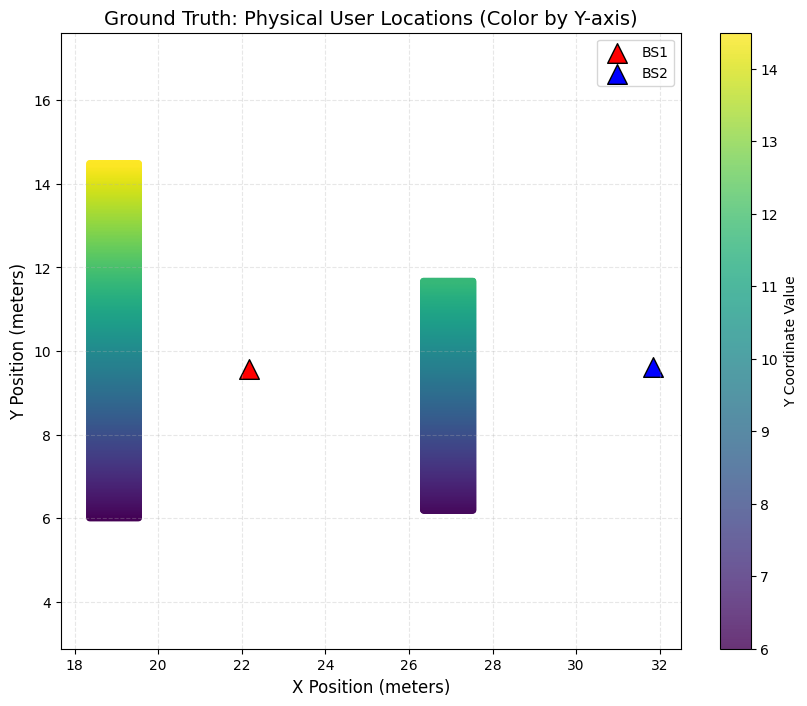

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 确保 dataset 已经加载
# user_locs shape: (N_users, 3) -> [x, y, z]
user_locs = dataset[0]['user']['location']
bs1_loc = dataset[0]['location']
bs2_loc = dataset[1]['location']

plt.figure(figsize=(10, 8))

# 1. 绘制用户真实位置 (Ground Truth)
# 关键：c=user_locs[:, 1] 表示用 Y 坐标的值来着色
# 这样你在看 PCA 或神经网络输出图时，如果颜色分布顺序与这张图一致，说明学习成功
sc = plt.scatter(user_locs[:, 0], user_locs[:, 1], 
                 c=user_locs[:, 1],  # 颜色依据
                 cmap='viridis',     # 颜色映射
                 s=10,               # 点的大小
                 alpha=0.8)          # 透明度

# 2. 绘制基站位置 (作为参考)
plt.scatter(bs1_loc[0], bs1_loc[1], c='red', marker='^', s=200, edgecolors='black', label='BS1')
plt.scatter(bs2_loc[0], bs2_loc[1], c='blue', marker='^', s=200, edgecolors='black', label='BS2')

# 3. 设置图表属性
plt.title("Ground Truth: Physical User Locations (Color by Y-axis)", fontsize=14)
plt.xlabel("X Position (meters)", fontsize=12)
plt.ylabel("Y Position (meters)", fontsize=12)
plt.axis('equal')  # 强制保持物理比例 (X轴和Y轴刻度间距相等)
plt.colorbar(sc, label='Y Coordinate Value') # 显示颜色条
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

传统基准方法对比（PCA\Isomap、t-SNE）

Running PCA...
Running Isomap...


/workspace/anaconda/envs/py39/lib/python3.9/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 3 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/workspace/anaconda/envs/py39/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/workspace/anaconda/envs/py39/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/workspace/anaconda/envs/py39/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._

Running t-SNE...


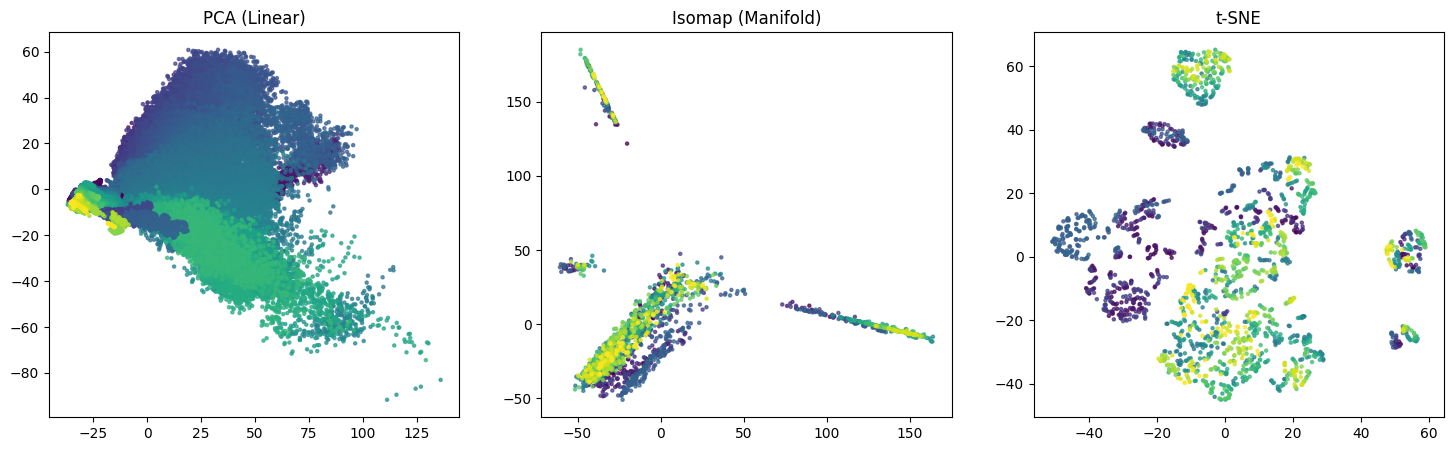

In [8]:
def plot_chart(embedding, true_locs, title, ax):
    """可视化辅助函数：根据真实位置对生成的图表进行着色"""
    # 使用 Y 轴坐标着色，观察拓扑保持性
    sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=true_locs[:, 1], cmap='viridis', s=5, alpha=0.7)
    ax.set_title(title)
    # ax.axis('equal') # 保持比例，视情况开启

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PCA
print("Running PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features)
plot_chart(X_pca, Y_locs, "PCA (Linear)", axes[0])

# 2. Isomap (流形学习)
print("Running Isomap...")
# n_neighbors 决定了局部邻域的大小
isomap = Isomap(n_components=2, n_neighbors=20) 
X_iso = isomap.fit_transform(X_features[:2000]) # 为了速度取前2000个点，全量可能很慢
plot_chart(X_iso, Y_locs[:2000], "Isomap (Manifold)", axes[1])

# 3. t-SNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_features[:2000])
plot_chart(X_tsne, Y_locs[:2000], "t-SNE", axes[2])

plt.show()

In [9]:
class CCDataset(Dataset):
    def __init__(self, features, locations, mode='triplet', dist_thresh=5.0):
        """
        mode: 'triplet' or 'siamese'
        dist_thresh: 物理空间中定义"邻居"的距离阈值 (米)
        """
        self.features = torch.FloatTensor(features)
        self.locations = locations
        self.mode = mode
        self.dist_thresh = dist_thresh
        self.num_samples = len(features)
        
        # 预先计算物理距离矩阵来寻找正负样本 (实际工程中可用KDTree优化)
        # 为了演示，我们在线随机采样或简化处理
        print("构建邻居索引 (可能需要几秒钟)...")
        self.nbrs = NearestNeighbors(radius=dist_thresh, algorithm='ball_tree').fit(locations)
        self.adj_matrix = self.nbrs.radius_neighbors(locations, return_distance=False)

    def __getitem__(self, index):
        anchor_feat = self.features[index]
        anchor_loc = self.locations[index]
        
        # 1. 寻找 Positive (物理距离近的)
        potential_positives = self.adj_matrix[index]
        if len(potential_positives) < 2:
            pos_idx = index # 只有自己，fallback
        else:
            pos_idx = np.random.choice(potential_positives)
        
        pos_feat = self.features[pos_idx]
        
        if self.mode == 'siamese':
            # Siamese 需要 label: 1(相似) 或 0(不相似)
            # 这里我们只生成正样本对用于这种特定的 Channel Charting 损失函数
            # 或者混合生成。为简化，这里实现 Triplet 为主，Siamese 仅返回 Pair
            return anchor_feat, pos_feat

        elif self.mode == 'triplet':
            # 2. 寻找 Negative (物理距离远的)
            # 简单策略：随机选一个，大概率是远的。
            # 严谨策略：检查距离 > 2 * dist_thresh
            neg_idx = np.random.randint(0, self.num_samples)
            while neg_idx in potential_positives:
                neg_idx = np.random.randint(0, self.num_samples)
            
            neg_feat = self.features[neg_idx]
            return anchor_feat, pos_feat, neg_feat

    def __len__(self):
        return self.num_samples

# 创建数据集
triplet_dataset = CCDataset(X_features, Y_locs, mode='triplet', dist_thresh=3.0)
triplet_loader = DataLoader(triplet_dataset, batch_size=128, shuffle=True, num_workers=0)

构建邻居索引 (可能需要几秒钟)...


In [10]:
class ChannelCharter(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=2):
        super(ChannelCharter, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim // 2),
            
            nn.Linear(hidden_dim // 2, output_dim) 
            # 输出层通常不加激活函数，以便覆盖整个2D空间
        )
        
    def forward(self, x):
        return self.encoder(x)

# 损失函数：三元组损失
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin
        self.relu = nn.ReLU()
        
    def forward(self, anchor, positive, negative):
        # 欧氏距离
        dist_pos = (anchor - positive).pow(2).sum(1)
        dist_neg = (anchor - negative).pow(2).sum(1)
        # Loss = max(0, d_pos - d_neg + margin)
        loss = self.relu(dist_pos - dist_neg + self.margin)
        return loss.mean()

# 实例化
input_dim = X_features.shape[1]
model = ChannelCharter(input_dim).to(device)
criterion = TripletLoss(margin=1.0) # Margin 越大，要求正负样本分得越开
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

ChannelCharter(
  (encoder): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Linear(in_features=128, out_features=2, bias=True)
  )
)


Epoch 1 Loss: 0.0280


Epoch 2 Loss: 0.0129


Epoch 3 Loss: 0.0096


Epoch 4 Loss: 0.0088


Epoch 5 Loss: 0.0080


...

Epoch 11 Loss: 0.0049


Epoch 12 Loss: 0.0046


Epoch 13 Loss: 0.0042


Epoch 14 Loss: 0.0043


Epoch 15 Loss: 0.0044


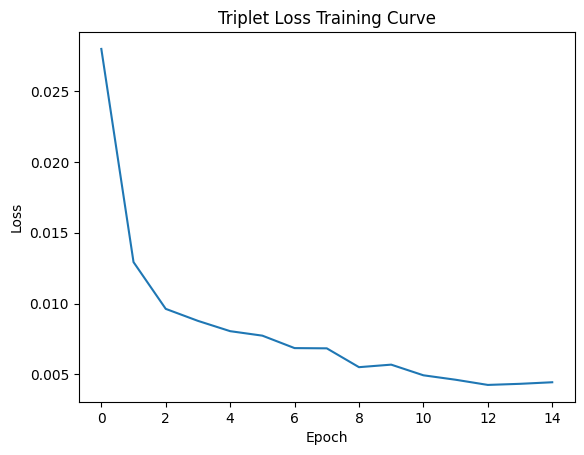

In [14]:
#训练循环
def train_model(model, loader, criterion, optimizer, epochs=20):
    model.train()
    loss_history = []
    
    for epoch in range(epochs):
        running_loss = 0.0
        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for batch in pbar:
            # 获取数据并放入 GPU
            anchor, positive, negative = batch
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)
            
            # 前向传播
            # Triplet/Siamese 特点：同一个网络处理不同输入
            embed_anchor = model(anchor)
            embed_pos = model(positive)
            embed_neg = model(negative)
            
            # 计算 Loss
            loss = criterion(embed_anchor, embed_pos, embed_neg)
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
            
        epoch_loss = running_loss / len(loader)
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch+1} Loss: {epoch_loss:.4f}")
        
    return loss_history

# 开始训练
history = train_model(model, triplet_loader, criterion, optimizer, epochs=15)

# 绘制 Loss 曲线
plt.figure()
plt.plot(history)
plt.title("Triplet Loss Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

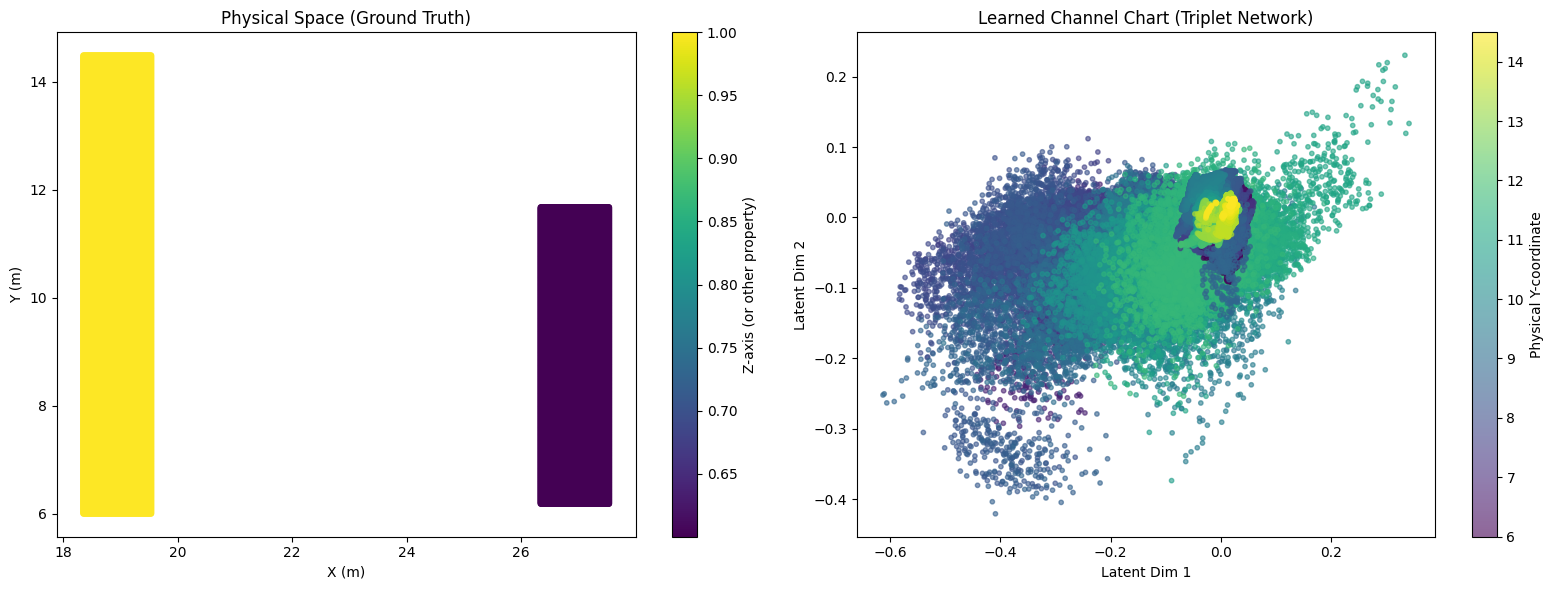

物理距离与Chart距离的相关系数 (Pearson Correlation): 0.3766
相关系数越高，代表 Chart 越好地保留了物理空间的距离关系。


In [12]:
#可视化
model.eval()
with torch.no_grad():
    # 全量推断
    inputs_tensor = torch.FloatTensor(X_features).to(device)
    chart_2d = model(inputs_tensor).cpu().numpy()

# 绘图对比
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 真实物理位置 (Ground Truth)
sc1 = axes[0].scatter(Y_locs[:, 0], Y_locs[:, 1], c=Y_locs[:, 2], cmap='viridis', s=10) # 颜色代表Z轴或其他
axes[0].set_title("Physical Space (Ground Truth)")
axes[0].set_xlabel("X (m)")
axes[0].set_ylabel("Y (m)")
plt.colorbar(sc1, ax=axes[0], label='Z-axis (or other property)')

# 2. 学习到的信道图 (Channel Chart)
# 使用物理位置的某个维度（如Y坐标）来给点着色，看颜色是否在图中有序过渡
sc2 = axes[1].scatter(chart_2d[:, 0], chart_2d[:, 1], c=Y_locs[:, 1], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title("Learned Channel Chart (Triplet Network)")
axes[1].set_xlabel("Latent Dim 1")
axes[1].set_ylabel("Latent Dim 2")
plt.colorbar(sc2, ax=axes[1], label='Physical Y-coordinate')

plt.tight_layout()
plt.show()

# 计算简单的评价指标：Trustworthiness (保序性) 或 距离相关系数
from scipy.stats import pearsonr
from scipy.spatial.distance import pdist

# 随机采样1000个点计算相关性（全量计算太慢）
idx_sample = np.random.choice(len(X_features), 1000, replace=False)
dist_phys = pdist(Y_locs[idx_sample])
dist_chart = pdist(chart_2d[idx_sample])
corr, _ = pearsonr(dist_phys, dist_chart)

print(f"物理距离与Chart距离的相关系数 (Pearson Correlation): {corr:.4f}")
print("相关系数越高，代表 Chart 越好地保留了物理空间的距离关系。")